<font size="6">**Fine-tuning per la classificazione**</font><br>
> *Copyright Antonio Piemontese 2025* (inspired to Sebastian Raschka's work).

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>Gli "innesti gpt-oss"</b> <i>(convenzione introdotta nel notebook 2)</i><br><br>
Nell'agosto 2025 OpenAI ha rilasciato <b>gpt-oss-120b</b> e <b>gpt-oss-20b</b>, i suoi primi modelli <i>open-weight</i> (cioè "a pesi aperti": i pesi sono liberamente scaricabili e utilizzabili, con licenza Apache 2.0) dopo GPT-2.<br><br>
Le celle come questa — su <u>sfondo azzurro</u> e contrassegnate dal simbolo 🧩 — sono <b>innesti gpt-oss</b>: nei punti di contatto con il programma del corso, anticipano <u>come cambia in gpt-oss</u> il concetto appena studiato su GPT-2. Sono <b>letture a margine</b>: il filo del corso resta GPT-2, e il confronto completo sarà sviluppato nel <b>modulo dedicato a gpt-oss</b> (notebook 8).<br><br>
Il tema di questo capitolo è il fine-tuning: gli innesti mostrano <b>come questo stesso capitolo si rifà, oggi, su gpt-oss</b>.
</div>

# Introduzione

Questo notebook tratta i seguenti argomenti:
* Introduzione a diversi **approcci di fine-tuning** degli  LLM
* **Preparazione di un dataset** per la classificazione del testo
* **Modifica** di un LLM pre-addestrato per il fine-tuning
* Fine-tuning di un LLM per **identificare messaggi di spam**
* Valutazione dell'**accuratezza** di un classificatore *fine-tuned*
* **Utilizzo** di un LLM fine-tuning per classificare nuovi dati

Finora abbiamo codificato l'architettura LLM, l'abbiamo pre-addestrata e abbiamo imparato come importare pesi pre-addestrati da una fonte esterna, come OpenAI, nel nostro modello.

Ora **raccoglieremo i frutti** del nostro lavoro facendo il *fine-tuning* dell'LLM su un'attività target specifica, come la classificazione del testo.

 L'esempio concreto che esamineremo è la classificazione dei messaggi di testo come "spam" o "non spam".

 La seguente figura evidenzia i due modi principali per fine-tuning di un LLM:
 - fine-tuning per la **classificazione** (fase 8)
 - e fine-tuning per **seguire le istruzioni** (fase 9).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/chapter-overview.webp" width=800px>

Questo notebook si focalizza sullo **stage 3**, il **passo 8**.

In [1]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.4 MB/s eta 0:00:00


In [ ]:
from importlib.metadata import version

pkgs = ["matplotlib",  # la libreria di plotting 
        "numpy",       # una dipendenza di PyTorch  
        "tiktoken",    # il Tokenizer
        "torch",       # la libreria di Deep Learning
        "tensorflow",  # per i pesi pre-allenati di OpenAI    
        "pandas"       # per caricare il dataset in un dataframe
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.0
numpy version: 2.0.2
tiktoken version: 0.9.0
torch version: 2.6.0+cu124
tensorflow version: 2.18.0
pandas version: 2.2.2


# Import dei moduli (classi e funzioni) degli altri notebook

La seguente cella contiene il codice Python contenuto nel seguente file (del sito):<br>
**ch06/01_main-chapter-code/previous_chapters.py**<br>
che definisce classi e funzioni dei notebook 2-3-4-5 necessari a questo notebook.

In [3]:
# Questo file raccoglie tutto il codice rilevante che abbiamo trattato finora
# nei notebook 2-5.
# Questo file può essere eseguito come script autonomo.
import numpy as np
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#####################################
# Notebook 2
#####################################


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


#####################################
# Notebook 3
#####################################
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


#####################################
# Notebook 4
#####################################
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_resid = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_resid(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_resid(x)
        x = x + shortcut  # Add the original input back

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx


#####################################
# Notebook 5
#####################################
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())

# Le differenti categorie di fine-tuning

I metodi più comuni di *fine-tuning* dei modelli linguistici sono il fine-tuning per **le istruzioni** e il fine-tuning per la  **classificazione**.

Il fine-tuning delle istruzioni consiste nell'addestrare un modello linguistico su una serie di attività **utilizzando istruzioni specifiche** per **migliorarne la capacità di comprendere ed eseguire** le attività descritte in prompt in linguaggio naturale, come illustrato nella seguente figura:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/instructions.webp" width=800px>

La figura illustra **due diversi scenari** di *instruction fine-tuning*. In alto, il modello ha il compito di determinare **se una data testo è spam**. In basso, al modello viene fornita un'istruzione su come tradurre una frase dall'inglese al tedesco.

Nel **fine-tuning per la classificazione** il modello è addestrato a **riconoscere un insieme specifico di etichette di classe**, come "spam" e "non spam". La classificazione va oltre gli LLM e il filtraggio delle email; includono:
- l'identificazione di diverse specie di piante dalle immagini
- la categorizzazione di articoli di notizie in base ad argomenti come sport, politica e tecnologia
- e la distinzione tra tumori benigni e maligni nell'imaging medico.

> Il **punto chiave** è che un modello di classificazione con fine-tuning **si limita a prevedere le classi che ha incontrato durante l'addestramento**. Ad esempio, può determinare se qualcosa è "spam" o "non spam", come illustrato nella seguente figura, ma **non può fornire ulteriori informazioni sul testo in input**.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/spam-non-spam.webp" width=(00px>

La figura illustra uno **scenario di classificazione del testo che utilizza un LLM**. Un modello *fine-tuned* (ottimizzato) per la classificazione dello spam <u>non richiede ulteriori istruzioni oltre all'input</u>. A differenza di un modello ottimizzato con istruzioni, **può rispondere solo** con "spam" o "non spam".

Possiamo pensare a un modello di classificazione *fine-tuned* come un modello molto specializzato; in pratica:
> è **molto più facile creare un modello specializzato** rispetto a un modello generalista che funzioni bene su molti compiti diversi

A differenza del modello di classificazione fine-tuned, un modello di <u>istruzione</u> fine-tuned può tipicamente svolgere **una gamma più ampia di compiti**.

---
> **Scelta dell'approccio corretto**<br>
>Il fine-tuning delle <u>istruzioni</u> migliora la capacità di un modello di comprendere e generare risposte basate su **specifiche istruzioni utente**. Il fine-tuning delle istruzioni è più adatto ai modelli che devono gestire una **varietà di attività basate su istruzioni utente complesse**, migliorando la flessibilità e la qualità dell'interazione.
>
>Il fine-tuning della <u>classificazione</u> è ideale per attività che richiedono una **categorizzazione precisa dei dati in classi predefinite**, come l'analisi del sentiment o il rilevamento dello spam.
>
>Sebbene il fine-tuning delle <u>istruzioni</u> sia **più versatile**, richiede <u>dataset più ampi</u> e <u>maggiori risorse computazionali</u> per sviluppare modelli competenti in varie attività.
>
>Al contrario, il fine-tuning della <u>classificazione</u> richiede **meno dati e potenza di calcolo**, ma il suo utilizzo è **limitato alle classi specifiche** su cui il modello è stato addestrato.
>
---

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Il punto di partenza è già diverso</b><br><br>
GPT-2 ci arriva "grezzo": solo pre-training, e sta a noi dargli un mestiere (qui: classificare; nel notebook 7: seguire istruzioni). gpt-oss arriva invece <b>già passato per il post-training</b>: è <i>instruction-tuned</i> e addestrato al ragionamento con il <b>reinforcement learning</b> (apprendimento per rinforzo: il modello viene premiato quando produce ragionamenti e risposte corretti).<br><br>
Dettaglio da conoscere: OpenAI ha pubblicato <u>solo le versioni post-addestrate</u> — la base "nuda" da solo pre-training non esiste in forma pubblica.<br><br>
Il fine-tuning di classificazione resta comunque sensato anche su un modello già istruito: lo <u>specializza su un compito</u> con i nostri dati, con i vantaggi di affidabilità descritti qui sopra. Cambia il <u>come</u>: lo vedremo negli innesti più avanti.
</div>

# Preparare il dataset

Modificheremo e perfezioneremo (*fine-tune*) per la classificazione **il
modello GPT** (`GPTModel`) precedentemente implementato e pre-addestrato.

Inizieremo scaricando e preparando il dataset, come evidenziato nella seguente figura. Per usare un **esempio intuitivo e utile** di fine-tuning della classificazione, lavoreremo con un dataset di messaggi di testo composto da messaggi spam e non spam.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/overview-1.webp" width=800px>

La figura illustra **il PROCESSO in TRE FASI** per il fine-tuningdi un LLM per la classificazione. La fase 1 prevede la **preparazione del dataset**. La fase 2 si concentra sulla **configurazione (*setup*) del modello**. La fase 3 riguarda il **vero e proprio *fine-tuning*, la valutazione del modello ed il suo utilizzo su dati nuovi**. Nota: i messaggi di testo vengono generalmente inviati via telefono, non via e-mail. Tuttavia, gli stessi passaggi si applicano anche alla classificazione delle e-mail e i lettori interessati possono trovare i link ai set di dati per la classificazione dello spam via e-mail nell'appendice B. Il primo passo è scaricare il set di dati.

---
***NOTA***<br>
I messaggi di testo vengono in genere inviati via telefono, non via email. Tuttavia, gli stessi passaggi si applicano anche alla classificazione **delle email**. E' disponibile, se di interesse, **anche il dataset per la classificazione dello spam via email**.

---

Il primo passo è scaricare il dataset.

In [4]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Download del file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzip del file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # aggiunge un'estensione .tsv
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


Ora il dataset è un file *separato da tab*, di nome `SMSSpamCollection.tsv`, nella cartella `sms_spam_collection`.<br>
Lo possiamo caricare in un [dataframe pandas](https://www.geeksforgeeks.org/python-pandas-dataframe/) nel seguente modo:

In [5]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


Esaminiamo la frequenza delle classi nel dataset:

In [6]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


Come si vede, la classe *ham* (cioè, non spam) è molto più frequente.

Per semplicità, e poiché preferiamo comunque un dataset **di piccole dimensioni per scopi didattici** (ciò consentirà di ottimizzare (*fine-tune*) più velocemente l'LLM), **sottocampioniamo** il dataset in modo che contenga **747 istanze per ciascuna classe**. Ciò serve anche a **bilanciare** le classi.

In [7]:
def create_balanced_dataset(df):

    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]

    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)

    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


Le classi ora sono bilanciate. Ora, convertiamo le etichette di classe in **numeri interi**: 0  e 1, rispettivamente.

In [8]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


Definiamo ora una funzione che **divide casualmente** il dataset in sottoinsiemi di **training, convalida e test**, con proporzioni 70,10,20 (tipiche del Machine Learning).

In [9]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

# Test size is implied to be 0.2 as the remainder
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

Nel Machine Learning e DeepLearning si usa a volte un terzo dataset intermedio, detto di "validazione" il cui scopo è confrontare le varie combinazioni di **iper-parametri** (NON confonderli con i parametri allenabili, i cui valori ottimali abbiamo trovato nel training) per trovare quelle più efficaci. A questo punto il test finale del modello sarà eseguito sui dati di test con il modello configurato con gli iper-parametri ottimali.

Salviamo i dataset come file *csv*, in modo da poterli usare più avanti.

In [10]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

**Ricapitolando**, abbiamo scaricato il dataset, lo abbiamo bilanciato e lo abbiamo suddiviso in sottoinsiemi per l'addestramento, la valutazioneed il test. Ora **configureremo i data loader di PyTorch** che useremo per addestrare il modello.

# Creare i *data loaders*

Svilupperemo i data loader di PyTorch in modo concettualmente simile a quanto fatto nei precedenti notebook con dati testuali. In quel contesto, avevamo utilizzato una tecnica a finestra mobile (**sliding window**) per generare **porzioni di testo di lunghezza uniforme**, che poi abbiamo <u>raggruppato in batch</u> per rendere l’addestramento del modello più efficiente. Ogni segmento costituiva un’istanza di addestramento.

Ora però stiamo lavorando con un dataset di spam che contiene messaggi di testo di **lunghezze variabili**. Per raggruppare questi messaggi in batch, come facevamo con i segmenti di testo, abbiamo **due opzioni principali**:

- TRONCARE tutti i messaggi alla lunghezza del messaggio più corto nel dataset (o nel batch).

- RIEMPIRE (*pad*) tutti i messaggi fino alla lunghezza del messaggio più lungo nel dataset (o nel batch).

La prima opzione è <u>meno costosa</u> a livello computazionale, ma può comportare **una perdita significativa di informazione**, soprattutto se i messaggi più brevi sono molto più corti rispetto alla media o ai messaggi più lunghi, con il rischio di ridurre le performance del modello.

Per questo motivo, **optiamo per la seconda opzione**, che preserva l’intero contenuto di ogni messaggio.

Per implementare questo **batching** con *padding* alla lunghezza del messaggio più lungo, **aggiungiamo dei token di padding a tutti i messaggi più brevi**. A tal fine, utilizziamo il token <|endoftext|> come <u>simbolo di padding</u>.

Tuttavia, invece di aggiungere direttamente la stringa <|endoftext|> ai messaggi testuali, possiamo **aggiungere l’ID token** corrispondente a <|endoftext|> ai messaggi già codificati, come illustrato nella seguente figura.

Il valore 50256 è l’ID token del token di padding <|endoftext|>. Possiamo verificare se l'ID del token è corretto codificando (*encoding*!) il token "<|endoftext|>" con il tokenizzatore GPT-2 del package `tiktoken` che abbiamo utilizzato in precedenza:



<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/pad-input-sequences.webp?123" width=800px>

La figura illustra il **processo di preparazione del testo in input**. Innanzitutto, ogni messaggio di testo in input viene convertito in una sequenza di ID token. Quindi, per garantire lunghezze uniformi delle sequenze, le sequenze più brevi vengono riempite (*padded*) con un token di riempimento (*padding token*) - in questo caso l'ID token 50256 - in modo che corrisponda alla lunghezza della sequenza più lunga.


In [11]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


Come si vede, il codice precedente restituisce [50256]

Dobbiamo prima implementare un **`Dataset` PyTorch**, che specifica come i dati vengono caricati ed elaborati prima di istanziare i `DataLoader`. A tale scopo, definiamo la classe `SpamDataset`, che implementa i concetti della figura precedente. La classe `SpamDataset` gestisce <u>diverse attività chiave</u>:
- codifica i messaggi di testo in sequenze di token,
- identifica la sequenza più lunga nel set di dati di addestramento
- e garantisce che tutte le altre sequenze vengano riempite (*padded*) con un token di riempimento (*padding token*) in modo che la loro lunghezza risulti uguale a quella della sequenza più lunga.

In [12]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenizziamo i testi
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Tronchiamo le sequenze più lunghe di max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Riempiamo (pad) le sequenze fino alla più lunga
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # Nota: una versione più "pythonica" di questo metodo
        # è la seguente, usata anche nel prossimo capitolo:
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)

La classe `SpamDataset` <u>carica i dati</u> dai file CSV creati in precedenza, <u>tokenizza il testo</u> utilizzando il tokenizzatore di GPT-2 `tiktoken` e ci consente di <u>aggiungere (*pad*) o troncare (*truncate*) le sequenze</u> a una lunghezza uniforme determinata dalla sequenza più lunga o da una lunghezza massima predefinita.

Questo garantisce che **ogni tensore di input abbia la stessa dimensione**, cosa necessaria per creare i batch nel `DataLoader` di training che implementiamo qui sotto:

In [14]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

 La lunghezza massima della sequenza è memorizzata nell'attributo `max_length` del dataset. Se sei curioso di vedere il numero di token nella sequenza più lunga, puoi usare il seguente codice:

In [15]:
print(train_dataset.max_length)

120


Il codice restituisce **120**, a dimostrazione del fatto che la sequenza più lunga <u>non contiene più di 120 token</u>, una lunghezza comune per i messaggi di testo.

Il modello può gestire sequenze <u>fino a 1.024 token</u> (il limite della *context length*). Quindi, se il tuo dataset include testi più lunghi, è possibile, al momento della creazione del dataset di training vista nel codice precedente, passare `max_length=1024` (anziché `None`), per garantire che i dati non superino la lunghezza di input (contesto) supportata dal modello.

Successivamente, aggiungiamo ai dataset di convalida e di test una lunghezza pari a quella della sequenza di training più lunga.

È importante notare che **tutti i campioni** dei dataset di convalida e di test che superano la lunghezza dell'esempio di training più lungo vengono troncati dall'istruzione `encoded_text[:self.max_length]` della classe `SpamDataset` definita prima. Questo troncamento è facoltativo; è possibile impostare `max_length=None` sia per i dataset di convalida che per quelli di test, a condizione che non vi siano sequenze che superano i 1.024 token in questi dataset.

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Il token di padding (eco del notebook 2)</b><br><br>
Qui riempiamo le sequenze con <b>50256</b>, l'ID di <code>&lt;|endoftext|&gt;</code> nel vocabolario di GPT-2. Con gpt-oss l'idea è identica, cambia solo il numero: in o200k_harmony <code>&lt;|endoftext|&gt;</code> vale <b>199999</b> (innesto del notebook 2).<br><br>
E l'alternativa accennata poco sopra — riempire <u>per batch</u> invece che per dataset — sarà la strada del notebook 7, identica anche per gpt-oss.
</div>

In [16]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

 ---
 **Esercizio** - <u>Aumentare la lunghezza del contesto</u><br>
 Aumenta gli input al numero massimo di token supportati dal modello e osserva come ciò influisce sulle prestazioni predittive.

Utilizzando i dataset come input, possiamo ora **istanziare i `DataLoader` in modo simile ai notebook precedenti (quando lavoravamo con dati di testo).

Tuttavia, in questo caso, i **target rappresentano le etichette di classe anziché i token successivi nel testo**. Ad esempio, se scegliamo una dimensione del batch di **8**, ogni batch sarà composto da **otto esempi di addestramento di lunghezza 120** e dalla **corrispondente etichetta di classe di ciascun esempio**, come illustrato nella figura seguente:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/batch.webp" width=800px>

La figura precedente illustra **un singolo batch di addestramento** <u>composto da</u> otto messaggi di testo rappresentati come ID token. Ogni messaggio di testo è composto da 120 ID token. Un' array di etichette di classe memorizza <u>le otto etichette di classe</u> corrispondenti ai messaggi di testo, che possono essere 0 ("non spam") o 1 ("spam").

Il codice della cella seguente **crea i data-loader** dei dataset di addestramento, convalida e test. I 3 data-loader caricano i messaggi di testo e le etichette in <u>batch di dimensione 8</u>.

In [17]:
from torch.utils.data import DataLoader

num_workers = 0   # questa impostazione garantisce la compatibilità con la maggior parte dei PC/laptop
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

<u>Per garantire</u> che i data-loader funzionino e restituiscano effettivamente batch delle dimensioni previste, eseguiamo **un'iterazione sul data-loader di addestramento** e quindi **stampiamo le dimensioni del tensore dell'ultimo batch**:

In [18]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


Come possiamo vedere, i batch di input sono <u>costituiti da otto esempi di addestramento con 120 token ciascuno</u>, **come previsto**. Il tensore dell'etichetta memorizza le etichette di classe **corrispondenti agli otto esempi di addestramento**.

Infine, per farci <u>un'idea delle dimensioni del dataset</u>, stampiamo il **numero totale di batch** in ogni dataset:

In [19]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


 Ora che abbiamo preparato i dati, dobbiamo **preparare il modello** per il *fine-tuning*


# Inizializzare un modello con pesi pre-allenati

Dobbiamo preparare il modello per il *fine-tuning* di classificazione dei messaggi di spam. Per prima cosa, **inizializziamo il nostro modello pre-addestrato**, come evidenziato nella seguente figura, che fa il **punto della situazione**.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/overview-2.webp" width=800px>

La figura precedente illustra il processo in tre fasi per il *fine-tuning* dell'LLM per la classificazione. Avendo completato la fase 1, ovvero la preparazione del dataset, dobbiamo ora inizializzare l'LLM.

Utilizziamo le STESSE configurazioni del modello che avevamo utilizzate per preaddestrare i dati non etichettati:

In [20]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Quale checkpoint</b><br><br>
Qui scegliamo tra le quattro taglie di GPT-2 e scarichiamo il 124M. L'equivalente per gpt-oss è il <b>20b da Hugging Face</b>, in MXFP4 (~13 GB: entra in una GPU consumer); il 120b per il fine-tuning resta fuori portata su hardware comune (tabella "Chi può allenare che cosa", notebook 5).<br><br>
E non c'è una scelta "base oppure istruito": come visto nell'innesto sulle categorie, esiste solo la versione post-addestrata.
</div>

Successivamente, importiamo la funzione `download_and_load_gpt2` dal file *gpt_download.py* e **riutilizziamo** la classe `GPTModel` e la funzione `load_weights_into_gpt` **dal pretraining** (vedere notebook 5) <u>per caricare nel modello GPT i pesi pre-allenati</u>.<br>

**Sono tre passi**; iniziamo <u>dal primo</u>: l'import della funzione `download_and_load_gpt2`

In [21]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch06/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7c648c204a50>)

In [22]:
from gpt_download import download_and_load_gpt2

Il <u>secondo</u> passo: scarichiamo i pesi del modelle pre-allenato. Occorre qualche minuto

In [23]:
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 84.0kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 929kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 118kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [01:33<00:00, 5.31MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 6.41MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 541kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 524kiB/s]


Il <u>terzo</u> passo: il caricamento di questi pesi (scaricati al passo precedente)  nell'istanza `model` della classe `GPTModel`:

In [24]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();                          # importante

Per <u>assicurarci</u> che il modello sia stato **caricato correttamente**, controlliamo attentamente che **generi un testo coerente**! A questo scopo usiamo la funzione utility vista nel notebook 5 (`generate_text_simple`) :

In [25]:
text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


Il testo generato:<br>
*Every effort moves you forward*.<br>
*The first step is to understand the importance of your work*.<br>
**è coerente**, il che significa che i pesi del modello sono stati caricati correttamente.


Prima di iniziare il fine-tuning del modello, vediamo - come curiosità - se il modello (pre-allenato) **è già, di suo, in grado di classificare i messaggi di spam**. A questo scopo proviamo a dargli le <u>istruzioni (di classificazione) via prompt</u>:

In [30]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


Come possiamo vedere, il modello non è molto bravo a seguire le istruzioni del prompt!.<br>
Ciò è prevedibile, dato che è stato solo pre-addestrato e non è stato oggetto di *fine-tuning* per istruzioni (che sarà trattata nel prossimo notebook).

# Aggiungere un classification head

Dopo avere caricato i pesi con successo, dobbiamo **modificare l'LLM pre-addestrato** per <u>ottimizzarlo (*fine-tune it*) per la classificazione</u>.

> In altre parole, il pre-allenamento è il **punto di partenza**, alla quale segue una **ottimizzazione** (*fine-tuning*) del modello pre-allenato <u>ad un certo scopo (qui la classificazione)</u>.

Per farlo, **sostituiamo il livello di output originale**, che mappa la rappresentazione nascosta a un vocabolario di 50.257, con un **livello di output più piccolo che mappa a due classi**: 0 ("non spam") e 1 ("spam"), come mostrato dalla seguente figura:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/lm-head.webp" width=800px>

La figura precedente illustra come avviene **l'adattamento di un modello GPT alla classificazione dello spam, tramite la modifica della sua architettura**. Inizialmente, il livello di output lineare del modello mappava 768 unità nascoste a un vocabolario di 50.257 token. Per rilevare lo spam, sostituiamo questo livello con un nuovo livello di output che mappa **le stesse 768 unità nascoste a due sole classi**, che rappresentano "spam" e "non spam".

---
> **Nodi del layer di output**<br>
> Tecnicamente potremmo utilizzare <u>un singolo nodo di output</u> (anzichè 2), dato che si tratta di un'attività di classificazione **binaria**. Tuttavia, ciò richiederebbe la modifica della *loss function* (funzione di perdita), come spiegato in ["Losses Learned—Optimizing Negative Log-Likelihood and Cross-Entropy in PyTorch"](https://mng.bz/NRZ2). Pertanto, scegliamo un **approccio più generale**, in cui il numero di nodi di output corrisponde al numero di classi. Ad esempio, per un problema a tre classi, come la classificazione di articoli di notizie come "Tecnologia", "Sport" o "Politica", utilizzeremmo tre nodi di output e così via.
>
---

Prima di effettuare la modifica al modello mostrata nella figura precedente, stampiamo **l’architettura del modello** tramite `print(model)`:

In [31]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

Questo output mostra in modo nitido e ben strutturato l'architettura implementata nel notebook 4.<br>
Come sappiamo, il modello `GPTModel` è composto da layer di embedding seguiti da 12 *transformer block* identici (per semplicità è mostrato solo l'ultimo), seguiti da un `LayerNorm` finale e dal layer di output (`out_head`).<br>


---
> **Ottimizzazione degli <u>ultimi</u> layer oppure di <u>tutti</u> i layer?**<br>
> Poiché partiamo da un modello pre-addestrato, **non è necessario ottimizzare tutti i layer del modello**. Nei modelli linguistici basati su reti neurali, infatti, i layer inferiori (i primi) generalmente **catturano le strutture linguistiche di base** e la semantica applicabile a <u>un'ampia gamma di attività e dataset</u>. Pertanto, ottimizzare solo gli ultimi layer (ovvero i layer vicini all'output), che sono più specifici per **pattern linguistici sfumati** e caratteristiche **specifiche dell'attività**, è SPESSO SUFFICIENTE per adattare (*fine-tune*) il modello a nuove attività. Inoltre, l'ottimizzazione di solo un piccolo numero di layer è **computazionalmente più efficiente**.
---

Come detto, dunque, l'obiettivo è dunque **sostituire e ottimizzare** il layer di output. Sostituiamo il layer `out_head` con il **nuovo layer di output**, che dovremo ottimizzare (vedi la figura precedente).

Per farlo, dobbiamo prima **congelare** (*freeze*) il modello, cioè rendere tutti i layer non addestrabili.

In [32]:
for param in model.parameters():
    param.requires_grad = False       # il freezing

Ora possiamo sostituire il layer di output (`model.out_head`), che originariamente mappava gli input del layer su 50.257 dimensioni (la dimensione del vocabolario) - vedi la figura precedente.<br>
Per mantenere il codice <u>più generale</u>, utilizziamo BASE_CONFIG["emb_dim"], che nel modello "gpt2-small (124M)" è pari a 768. In questo modo, possiamo utilizzare lo **stesso codice anche per le varianti più grandi del modello GPT-2**.

In [33]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

Questo nuovo layer di output, che abbiamo chiamato `model.out_head`, ha l'attributo `requires_grad` impostato su `True` **per default**, il che significa che è **l'unico layer del modello che verrà aggiornato durante l'addestramento** (il fine-tuning). [Tutti gli altri layer li abbiamo infatti congelati].

Tecnicamente, l'addestramento del layer di output appena aggiunto è <u>sufficiente</u>. Tuttavia, gli esperimenti di diversi ricercatori, ad esempio [questo](https://magazine.sebastianraschka.com/p/finetuning-large-language-models), hanno dimostrato che:
> la messa a punto (*fine-tuning*) di layer **aggiuntivi** può **migliorare** notevolmente le prestazioni.

**Quindi**, rendiamo addestrabili anche l'ultimo blocco trasformatore e il modulo `LayerNorm` finale che collega l'ultimo blocco trasformatore al livello di output. Vedi la figura seguente:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/trainable.webp" width=600px>

La figura illustra l'architettura **ulteriormente modificata**. Oltre al layer di output, cioè, impostiamo come addestrabili (*trainable*) **anche** il `LayerNorm` finale e l'ultimo blocco transformer. I restanti 11 blocchi transformer e i livelli di embedding sono <u>invece</u> mantenuti non addestrabili.

Per rendere addestrabili il `LayerNorm` finale e l'ultimo blocco transformer, impostiamo i rispettivi `requires_grad` su `True`:

In [34]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Testa nuova e congelamento: l'idea regge, la tattica cambia</b><br><br>
L'idea appena implementata vale <u>identica</u> per gpt-oss: si sostituisce il layer di uscita con una <b>testa a 2 nodi</b> (lì: da 2.880 → 2, al posto della matrice di unembedding da ~0,58 miliardi di parametri — notebook 4) e si classifica sull'<b>ultimo token</b>, per la stessa ragione causale.<br><br>
Cambia la <u>tattica del congelamento</u>. Qui "congelare tutto tranne ultimo blocco + LayerNorm finale + testa" funziona perché i 124M stanno comodi in memoria; sul 20b il collo di bottiglia non sono i gradienti ma <u>i pesi congelati stessi</u> (~42 GB in bf16). La soluzione moderna: <b>base quantizzata a 4 bit + LoRA</b> (notebook 5) — invece di "scongelare l'ultimo blocco", si affiancano piccole matrici adattatrici agli strati di attenzione e MLP di <u>tutti</u> i blocchi: stesso spirito (pochi parametri allenabili), distribuito su tutto il modello. In pratica, con librerie come <code>peft</code> o Unsloth.<br><br>
Invariati: <code>requires_grad</code> come interruttore concettuale, e la loss sull'ultimo token (prossimo innesto).
</div>

---
> **Esercizio  - Ottimizzazione dell'intero modello**<br>
> Invece di ottimizzare solo il blocco transformer finale, ottimizza l'intero modello e valuta l'effetto sulle prestazioni predittive.
---

A prescindere dalle modifiche architetturali ora fatte, possiamo **utilizzare questo modello in modo simile a come abbiamo fatto in precedenza**. Ad esempio, possiamo fornirgli un testo di esempio identico al testo di esempio utilizzato in precedenza:

In [35]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


Come si vede, il codice precedente ha codificato (*encoded*) gli input in un **tensore di 4 input token l'uno**.




Ora, possiamo passare i token IDs *encoded* al modello, come sempre:

In [36]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


Questo input (*Do you have time*) precedentemente avrebbe prodotto **un tensore di output pari a [1, 4, 50257]**, dove 50257 rappresenta la dimensione del vocabolario. Come visto nei notebook precedenti, **per ogni token di input esiste un vettore di output**, cioè il numero di righe di output **corrisponde** al numero di token di input (in questo caso, quattro). Tuttavia, la dimensione di incorporamento (*embedding*) di ciascun output (il numero di colonne) è ora pari a 2 anziché 50.257, poiché abbiamo sostituito il layer di output del modello. Ricordiamo che siamo interessati a ottimizzare questo modello per restituire un'etichetta di classe che indichi se un input del modello è "spam" o "non spam". **Non è necessario ottimizzare tutte e quattro le righe di output**; possiamo concentrarci **su un singolo token di output**. In particolare, ci concentreremo <u>sull'ultima riga</u> corrispondente <u>all'ultimo token di output</u>, come mostrato nella seguente figura:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/input-and-output.webp" width=600px>

 La figura illustra il modello GPT con **un esempio di input e di output di quattro token**. Il tensore di output è costituito da due colonne a causa del livello di output modificato. Quando si ottimizza per la classificazione (*classification fine-tuning*), in questo caso di testo *spam*, si è interessati solo all'**ultima riga**, corrispondente all'ultimo token. [Adesso spieghiamo perchè]

Per estrarre <u>l'ultimo token di output</u> dal tensore di output, utilizziamo il seguente codice:

In [37]:
print("l'ultimo token di output:", outputs[:, -1, :])

l'ultimo token di output: tensor([[-3.5983,  3.9902]])


Dobbiamo **convertire** i valori in una <u>previsione di etichetta di classe</u>.

Ma prima, capiamo perché siamo **particolarmente interessati solo all'ultimo token di output**.

Nei precedenti notebook abbiamo già esplorato il **meccanismo dell'attenzione**, che:
> stabilisce <u>una relazione</u> tra ciascun token di input e ogni altro token di input<br>

e il concetto di maschera di attenzione causale (*causal attention mask*), comunemente utilizzato nei modelli di tipo GPT (vedi il notebook 3).

Questa maschera, come sappiamo, **limita il focus di un token** alla sua posizione corrente e a quelle precedenti, assicurando che ogni token possa essere influenzato solo da se stesso e dai token precedenti, e non da quelli successivi, come illustrato nella seguente figura:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/attention-mask.webp" width=400px>

La figura illustra il **meccanismo dell'attenzione causale** (*causal attention mask*), in cui i punteggi di attenzione tra i token di input sono **visualizzati in formato matriciale**. Le celle vuote indicano <u>posizioni mascherate a causa della maschera di attenzione causale</u>, che **impedisce ai token di prestare attenzione ai token futuri**. I valori nelle celle rappresentano i punteggi di attenzione; l'ultimo token, *time*, è **l'unico** per cui si calcolano i punteggi di attenzione per <u>tutti</u> i token precedenti.

Nella configurazione della maschera di attenzione causale, come quella mostrata in figura,
> l'ULTIMO token della sequenza **accumula la maggior parte delle informazioni poiché è l'UNICO token con accesso ai dati di TUTTI i token precedenti**.

Pertanto siamo <u>molto interessati ad esso</u> e, nella nostra attività di classificazione dello spam, durante il processo di ottimizzazione (*fine-tuning*) ci **concentriamo su quest'ultimo token**.

Ora, finalmente, siamo pronti a **convertire** (cioè, trasformare) il valore (dell'**ultimo token**) in una <u>previsione di etichetta di classe</u> e **calcolare l'accuratezza di previsione** iniziale del modello. Successivamente, ottimizzeremo (*we'll fine-tune*) il modello per l'attività di classificazione dello spam.

---
> **Esercizio -- Ottimizzazione del primo o dell'ultimo token**<br>
> Provate ad ottimizzare il <u>primo</u> token di output. Notate i cambiamenti nelle prestazioni predittive rispetto all'ottimizzazione dell'<u>ultimo</u> token di output.
---

# Calcolare la loss e l'accuratezza della classificazione

Prima di ottimizzare il modello, resta solo una piccola attività: dobbiamo **implementare le funzioni di valutazione del modello** (che poi utilizzeremo durante il fine-tuning), come illustrato nella figura seguente:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/overview-3.webp?1" width=700px>

La figura illustra il processo in tre fasi per il fine-tuning del modello per la classificazione, che abbiamo già visto diverse volte. <u>Abbiamo completato i primi sei passaggi</u>. Siamo ora pronti per intraprendere <u>l'ultimo passaggio della fase 2</u>: **implementare le funzioni di valutazione delle prestazioni del modello** nella classificazione dei messaggi spam, **PRIMA**, **DURANTE** e **DOPO** il fine-tuning.

Prima di implementare le utilità di valutazione, vediamo brevemente **come convertire** gli output del modello in previsioni delle etichette di classe. In precedenza (<u>negli scorsi notebook</u>) calcolavamo l'ID del token successivo, generato dall'LLM, **convertendo** i 50.257 output (*logits*) in probabilità, tramite la funzione `softmax`, e restituendo quindi la posizione della probabilità più alta tramite la funzione `argmax`.

Adottiamo lo STESSO  approccio anche qui per calcolare se il modello genera una previsione "spam" o "non spam" per un dato input, come mostrato nella figura seguente. L'unica differenza è qui che lavoriamo con **output a 2 dimensioni invece che a 50.257 dimensioni**.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/class-argmax.webp" width=1000px>

La figura come gli output del modello corrispondenti all'**ultimo token** sono **convertiti** in punteggi di probabilità (*probability scores*) per ciascun testo di input. Le etichette di classe si ottengono cercando (*looking up*) la posizione dell'indice con il punteggio di probabilità più alto. **Il modello prevede le etichette spam in modo errato perché non è ancora stato addestrato!**

Consideriamo nuovamente l'**ultimo** token di output dell'esempio di prima, che avevamo già visualizzato:

In [41]:
print("l'ultimo token di output:", outputs[:, -1, :])

l'ultimo token di output: tensor([[-3.5983,  3.9902]])


Come nel notebook 5, convertiamo gli  outputs (*logits*) in "probability scores" (cioè, probabilità) tramite la funzione `softmax` e quindi otteniamo la posizione dell'indice del valore di probabilità più alto tramite la funzione `argmax`:

In [42]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


In questo caso il codice restituisce 1, cioè il modello prevede che l'input sia *spam*. In realtà, la funzione `softmax` qui NON è necessaria perchè gli output maggiori corrispondono direttamente alle probabilità più alte. Perciò possiamo semplificare il codice in questo modo (senza `softmax`):

In [43]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


Questo concetto può essere utilizzato per **calcolare l'accuratezza della classificazione**, che misura la <u>percentuale di previsioni corrette in un dataset</u>. A questo scopo applichiamo il **codice di previsione basato su `argmax`, visto prima, a TUTTI gli esempi nel dataset** e calcoliamo la **percentuale di previsioni corrette** definendo una funzione `calc_accuracy_loader`.

In [44]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

Usiamo questa funzione per calcolare l'accuratezza della classificazione **su vari dataset stimati da 10 batch**:

In [45]:
torch.cuda.is_available()

False

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Nota:
# Rimuovendo il commento dalle seguenti righe, il codice potrà essere eseguito sui chip Apple Silicon, se applicabile,
# che sono circa 2 volte più veloci rispetto a una CPU Apple (come misurato su un MacBook Air M3).
# A fine 2024, con PyTorch 2.4, i risultati ottenuti tramite CPU e MPS erano identici.
# Tuttavia, nelle versioni precedenti di PyTorch, si potrebbero osservare risultati diversi utilizzando MPS.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")
#print(f"Running on {device} device.")

model.to(device)       # per le classi nn.Module l'assegnazione 'model = model.to(device) NON è necessaria

torch.manual_seed(123) # per la riproducibilità, a causa dello "shuffling" (rimescolamento) nel data-oader di training

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

cpu
Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


Come possiamo vedere, l'accuratezza della previsione è **vicina a una previsione casuale**, che in questo caso sarebbe del 50%. Per migliorare l'accuratezza della previsione, **dobbiamo ottimizzare il modello**.

Prima di iniziare l'ottimizzazione (*fine-tuning*) del modello, dobbiamo **definire la funzione di perdita (*loss function*)** che ottimizzeremo (minimizzeremo) durante l'addestramento. Il nostro obiettivo è massimizzare l'accuratezza della classificazione dello spam del modello, il che significa che il codice precedente dovrebbe restituire le etichette di classe corrette: 0 per non spam e 1 per spam. Poiché l'accuratezza della classificazione <u>NON è una funzione differenziabile</u>, utilizziamo la ***cross-entropy loss*** come proxy per massimizzare l'accuratezza. Altre info [qui](https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression) alla *lecture 8*.

Di conseguenza, la funzione `calc_loss_batch` rimane la stessa del notebook 5, con una modifica: ci concentriamo sull'ottimizzazione del **solo ultimo token**, `model(input_batch)[:, -1, :]`, anziché di tutti i token, `model(input_batch)`:

In [47]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

Utilizziamo la funzione `calc_loss_batch` per **calcolare la perdita per un singolo batch** ottenuto dai data loader definiti in precedenza. Per calcolare la perdita per tutti i batch in un data loader, definiamo la funzione `calc_loss_loader` come in precedenza (notebook 5).

In [48]:
# lo stesso loader del notebook 5
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
    # riduce il numero di batch in modo che corrisponda al numero totale di batch nel data-loader
    # se 'num_batches' supera il numero di batch nel caricatore dati
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In modo simile al calcolo dell'accuratezza, tramite `calc_closs_loader` calcoliamo le perdite iniziali per ogni dataset (training, validazione e test) prima di iniziare il training:



In [49]:
with torch.no_grad(): # disabilitare il tracciamento del gradiente per efficienza (perché non stiamo ancora allenando il modello)
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


Nel prossimo capitolo, implementeremo una **funzione di training per il fine-tuning del modello**, che significa aggiustare il modello (i suoi pesi) per minimizzare la funzione di perdita.
> Minimizzare la perdita del training setcontribuirà ad aumentare l'accuratezza della classificazione, che è il **nostro obiettivo generale**.

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Loss e accuratezza: identiche</b><br><br>
La cross-entropia sull'ultimo token e l'accuratezza appena definite si trasferiscono su gpt-oss <u>senza cambiare una riga</u>: sono proprietà del <b>compito</b> (classificare con un modello causale), non del modello. E vale anche la scelta dell'ultimo token, discussa nell'esercizio poco sopra: con l'attenzione causale è l'unico token che "ha visto" l'intero messaggio.
</div>

# Il playground di TensorFlow
Potete **esercitarvi** [qui](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.11801&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) a creare reti neurali feed-forward <u>per la classificazione</u> e vedere l'effetto che fa.<br>
**Non crea codice!**

# Il Fine-tuning del modello su dati supervisionati

Dobbiamo **definire e utilizzare la funzione di training per ottimizzare (*fine-tune*) l'LLM pre-addestrato e migliorarne l'accuratezza nella classificazione dello spam**. Il ciclo di training, illustrato nella seguente figura, è lo stesso ciclo di training complessivo che abbiamo utilizzato per il pre-training; l'unica differenza è che calcoliamo l'accuratezza della classificazione invece di generare un testo di esempio per valutare il modello.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/training-loop.webp?1" width=500px>

La figura illustra un tipico ciclo di addestramento per reti neurali profonde, che in PyTorch consiste in diversi passaggi, che iterano sui batch del training set per diverse epoche. In ogni ciclo, calcoliamo la perdita per ciascun batch del training set per determinare i gradienti di perdita, che utilizziamo per aggiornare i pesi del modello al fine di minimizzare la perdita del training set.

La funzione di training `train_classifier_simple` implementa i concetti mostrati nella figura e rispecchia da vicino anche la funzione `train_model_simple` utilizzata per il pre-training del modello (nel notebook 5). Le uniche due differenze sono che ora tracciamo il numero di esempi di training visualizzati (`examples_seen`) invece del numero di token, e calcoliamo l'accuratezza **dopo ogni epoca** invece di visualizzare un testo di esempio.

In [38]:
# Complessivamente lo stesso che in `train_model_simple` del notebook 5
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

La funzione `evaluate_model` utilizzata in `train_classifier_simple` è la stessa che abbiamo utilizzato nel notebook 5.

In [39]:
# lo stesso del notebook 5
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

Quiindi, inizializziamo l'ottimizzatore, impostiamo il numero di epoche di addestramento e **avviamo l'addestramento** (il *fine-tuning*!!) utilizzando la funzione `train_classifier_simple`.<br>
L'addestramento richiede:
- circa **15 minuti** su CPU di Google Colab
- circa **6 minuti** su un laptop MacBook Air M3
- meno di un minuto su L4 GPU di Google Colab
- meno di mezzo minuto su una GPU V100 o A100 di Google Colab

In [50]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 14.88 m

Come nel notebook 5, anche qui usiamo il package `matplotlib` per plottare la loss function per il dataset di training e di validazione:

In [51]:
import matplotlib.pyplot as plt

# definizione della funzione di plot
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

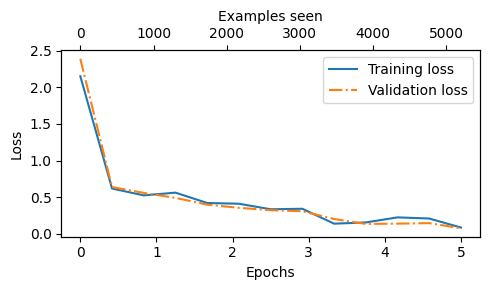

In [54]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

La figura illustra l'andamento della funzione di perdita di addestramento e convalida nelle cinque epoche di addestramento.

Sia la perdita di addestramento, rappresentata dalla linea continua, sia la perdita di convalida, rappresentata dalla linea tratteggiata, diminuiscono bruscamente nella prima epoca e si stabilizzano gradualmente verso la quinta epoca.

Questo andamento indica un buon progresso di apprendimento e suggerisce che il modello ha appreso dai dati di addestramento, generalizzando bene ai dati di convalida non osservati.

Il fatto che la perdita di addestramento e di convalida siano sempre molto vicine indica che il modello non tende a sovra-adattare i dati di addestramento



---
**Scelta del numero di epoche**<br>
In precedenza, quando abbiamo avviato l'addestramento, abbiamo impostato il numero di epoche a cinque. Il numero di epoche dipende dal dataset e dalla difficoltà del compito e non esiste una soluzione o una raccomandazione universale, sebbene **un numero di epoche pari a cinque sia solitamente un buon punto di partenza**. Se il modello presenta un **overfitting** dopo le prime epoche, potrebbe essere necessario **ridurre** il numero di epoche. Al contrario, se la linea di tendenza suggerisce che la perdita di validazione potrebbe migliorare con un ulteriore addestramento, è opportuno aumentare il numero di epoche. In questo caso concreto, cinque epoche sono un numero ragionevole, in quanto non vi sono segni di overfitting precoce e la perdita di validazione è prossima a 0.

---

Allo stesso modo, con la funzione `plot_values` possiamo plottare le due accuratezze:

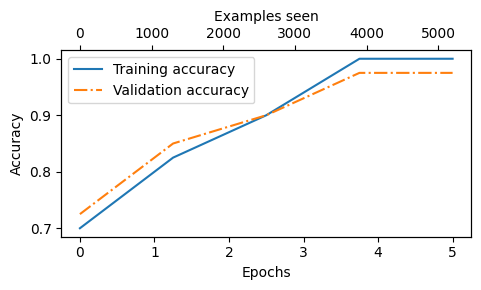

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

Come si vede nel grafico, sia l'accuratezza dell'addestramento (linea continua) che l'accuratezza della convalida (linea tratteggiata) aumentano sostanzialmente nelle prime epoche e poi si stabilizzano, raggiungendo punteggi di accuratezza quasi perfetti di 1.0. La stretta vicinanza delle due linee durante le epoche suggerisce nuovamente il modello NON va significative in overfit sui dati di training.

Tuttavia, dobbiamo tenere presente che in precedenza abbiamo specificato `eval_iter=5` nella funzione di training, il che significa che, <u>per ragioni di efficienza</u>, abbiamo solo **stimato**  le prestazioni del training set e del validation set (**su 5 batch**).

Possiamo calcolare le prestazioni del training set, del validation set e del test set sull'**intero dataset** (cioè senza definire il valore di `eval_iter`) come segue.

In [52]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


Le prestazioni del training e del test set sono quasi identiche. La leggera discrepanza tra le accuratezze del training e del test set suggerisce un minimo overfitting dei dati di training.

In genere, l'accuratezza del validation set è leggermente superiore a quella del test set perché lo sviluppo del modello spesso comporta l'ottimizzazione degli iperparametri per ottenere buone prestazioni sul validation set, che potrebbe non essere generalizzata in modo altrettanto efficace al test set.

Questa situazione è comune, ma il divario potrebbe potenzialmente essere ridotto al minimo regolando le impostazioni del modello, ad esempio aumentando il tasso di abbandono (`drop_rate`) o il parametro `weight_decay` nella configurazione dell'ottimizzatore.


Dopo aver ottimizzato e valutato il modello, siamo ora pronti a classificare i messaggi di spam, come di vede dalla seguente figura:


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/overview-4.webp" width=800px>

La figura rappresenta l'ormai noto processo in tre fasi per il fine-tuining del nostro modello per la classificazione. Il passaggio 10 è il passaggio finale della fase 3: l'utilizzo del modello perfezionato per classificare i nuovi messaggi di spam.

Per finire, vediamo dunque il modello GPT ottimizzato in azione.<br>
La funzione `classify_review` qui sotto implementa i passaggi di pre-elaborazione dei dati in modo simile a `SpamDataset` implementato in precedenza.<br>
Quindi, la funzione restituisce l'etichetta della classe intera prevista dal modello e il nome della classe corrispondente.

In [55]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepariamo gli input per il modello
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Nota: nel libro qui c'era per errore pos_emb.weight.shape[1]
    # Non rompeva il codice, ma avrebbe causato un troncamento inutile (a 768 invece di 1024)

    # Tronchiamo le sequenze troppo lunghe
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Riempiamo (pad) le sequenze fino alla più lunga
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Inferenza del modello
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Restituiamo il risultato della classificazione
    return "spam" if predicted_label == 1 else "not spam"

Proviamo la funzione `classify_review` su un testo di esempio:

In [56]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


Il modello prevede correttamente `spam`.<br>
Proviamola su un altro testo di esempio:

In [57]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


Il modello prevede correttamente `not spam`.

Infine, **salviamo il modello** nel caso in cui volessimo **riutilizzarlo in seguito** senza doverlo addestrare nuovamente:

In [58]:
torch.save(model.state_dict(), "review_classifier.pth")

Una volta salvato, in un'altra sessione il modello potrà essere **ricaricato** così:

In [59]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Questo capitolo, rifatto sul 20b: la ricetta</b><br><br>
Il percorso appena completato si rifà su gpt-oss-20b in cinque passi concettuali:<br><br>
1️⃣ caricare la base in 4 bit (~13 GB);<br>
2️⃣ agganciare gli <b>adattatori LoRA</b> — gli unici parametri con <code>requires_grad=True</code>;<br>
3️⃣ stessa testa a 2 classi e stessa loss sull'ultimo token di questo capitolo;<br>
4️⃣ stesso ciclo di training (il nostro <code>train_classifier_simple</code>, concettualmente);<br>
5️⃣ salvare <u>solo gli adattatori</u>: non uno <code>state_dict</code> intero da ~0,6 GB come il nostro <code>review_classifier.pth</code>, ma <b>qualche decina di MB</b> — la base resta il file scaricato.<br><br>
Tempi: su una GPU da ~14 GB, con un dataset come questo, parliamo di minuti — Colab incluso. Lo faremo per davvero nel modulo pratico (notebook 9).
</div>

# Sintesi e messaggi takeaway

* Esistono diverse **strategie** per la messa a punto (*fine-tuning*) degli LLM, tra cui il fine-tuning della <u>classificazione</u> e il fine-tuning di <u>istruzioni</u>
* Il fine-tuning della classificazione comporta la sostituzione del layer di output di un LLM con **un piccolo livello di classificazione**
* Nel caso della classificazione dei **messaggi di testo** come "spam" o "non spam", il nuovo layer di classificazione è costituito da soli **due nodi di output**. In precedenza, utilizzavamo un numero di nodi di output pari al numero di token univoci nel vocabolario (ovvero 50.256)
* Invece di prevedere il token successivo nel testo (come si fa nel pre-addestramento), il fine-tuing della classificazione addestra il modello a **restituire un'etichetta di classe corretta**, ad esempio "spam" o "non spam"
* L'**input del modello** per il fine-tuning è un **testo convertito in ID token**, in modo simile al pre-addestramento
* Prima di fare il fine-tuning, **carichiamo il modello pre-addestrato come modello base**
* La valutazione di un modello di classificazione comporta il calcolo dell'**accuratezza** della classificazione (la frazione o percentuale di previsioni corrette)
*  Il fine-tuning di un modello di classificazione utilizza la stessa funzione di perdita **cross entropy loss** utilizzata durante il pre-addestramento dell'LLM.

- Vedi lo script [./gpt_class_finetune.py](./gpt_class_finetune.py), uno script autonomo per il fine-tuning di classificazione
- Le soluzioni degli esercizi sono in [./exercise-solutions.ipynb](./exercise-solutions.ipynb)
- Inoltre, per chi è interessato, un'introduzione all'addestramento efficiente nei parametri con la *low-rank adaptation* (**LoRA**) si trova nell'[appendice E](../../appendix-E)

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>Riepilogo degli innesti — da GPT-2 a gpt-oss (capitolo 6)</b><br><br>
<table style="border-collapse:collapse">
<tr><th style="border:1px solid #9bb8d3; padding:6px 10px; background:#d6e8fb; text-align:left">Aspetto</th><th style="border:1px solid #9bb8d3; padding:6px 10px; background:#d6e8fb; text-align:left">GPT-2 124M (questo corso)</th><th style="border:1px solid #9bb8d3; padding:6px 10px; background:#d6e8fb; text-align:left">gpt-oss-20b</th></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Punto di partenza</td><td style="border:1px solid #9bb8d3; padding:6px 10px">base "grezza" (solo pre-training)</td><td style="border:1px solid #9bb8d3; padding:6px 10px">già post-addestrato (nessuna base pubblicata)</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Checkpoint</td><td style="border:1px solid #9bb8d3; padding:6px 10px">124M via <code>gpt_download</code></td><td style="border:1px solid #9bb8d3; padding:6px 10px">20b da Hugging Face, MXFP4 (~13 GB)</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Testa di classificazione</td><td style="border:1px solid #9bb8d3; padding:6px 10px">Linear 768 → 2</td><td style="border:1px solid #9bb8d3; padding:6px 10px">Linear 2.880 → 2</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Token su cui si classifica</td><td style="border:1px solid #9bb8d3; padding:6px 10px">l'ultimo</td><td style="border:1px solid #9bb8d3; padding:6px 10px">l'ultimo (identico)</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Strategia sui parametri</td><td style="border:1px solid #9bb8d3; padding:6px 10px">congelare tutto tranne ultimo blocco + norm + testa</td><td style="border:1px solid #9bb8d3; padding:6px 10px">base 4-bit congelata + adattatori LoRA</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Loss e metrica</td><td style="border:1px solid #9bb8d3; padding:6px 10px">CE sull'ultimo token, accuratezza</td><td style="border:1px solid #9bb8d3; padding:6px 10px">identiche</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Cosa si salva</td><td style="border:1px solid #9bb8d3; padding:6px 10px">intero <code>state_dict</code> (~0,6 GB)</td><td style="border:1px solid #9bb8d3; padding:6px 10px">soli adattatori LoRA (decine di MB)</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Hardware</td><td style="border:1px solid #9bb8d3; padding:6px 10px">qualsiasi GPU</td><td style="border:1px solid #9bb8d3; padding:6px 10px">~14 GB di VRAM (QLoRA); 120b ✘</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Token di padding</td><td style="border:1px solid #9bb8d3; padding:6px 10px">50256</td><td style="border:1px solid #9bb8d3; padding:6px 10px">199999</td></tr>
</table>
<br>
La ricetta, eseguita per davvero, è nel <b>modulo pratico</b> (notebook 9, <i>"gpt-oss in pratica"</i>); il confronto architetturale completo resta nel notebook 8.
</div>